# **Read dataset**

In [1]:
import numpy as np
import pandas as pd
train_path = 'C:/Users/Natha/Documents/UMN/Semester 5/Machine Learning/Dataset/credit_card_transaction_train.csv'
test_path = 'C:/Users/Natha/Documents/UMN/Semester 5/Machine Learning/Dataset/credit_card_transaction_test.csv'
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# **Dataset Information**

In [2]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [3]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

# **Data Pre-processing**

## Null Check

In [4]:
df_train.isnull().sum()

Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64

In [5]:
df_test.isnull().sum()

Unnamed: 0                   0
trans_date_trans_time        0
cc_num                       0
merchant                     0
category                     0
amt                          0
first                        0
last                         0
gender                       0
street                       0
city                         0
state                        0
zip                          0
lat                          0
long                         0
city_pop                     0
job                          0
dob                          0
trans_num                    0
unix_time                    0
merch_lat                    0
merch_long                   0
is_fraud                     0
merch_zipcode            83983
dtype: int64

In [6]:
new_df_train = df_train
new_df_test = df_test

## Remove Prefix in merchant

In [7]:
new_df_train['merchant'] = new_df_train['merchant'].str.removeprefix('fraud_')
new_df_test['merchant']  = new_df_test['merchant'].str.removeprefix('fraud_')

## Fill in null values in merch_zipcode

In [8]:
new_df_train['merch_zipcode'] = new_df_train['merch_zipcode'].fillna(new_df_train['merch_zipcode'].median())
new_df_test['merch_zipcode'] = new_df_test['merch_zipcode'].fillna(new_df_test['merch_zipcode'].median())

## Feature Engineering

### Feature Extraction from trans_date_trans_time

In [9]:
# Feature 1
new_df_train['trans_date_trans_time'] = pd.to_datetime(new_df_train['trans_date_trans_time'])
new_df_test['trans_date_trans_time']  = pd.to_datetime(new_df_test['trans_date_trans_time'])

# Feature 2
new_df_train['dob'] = pd.to_datetime(new_df_train['dob'])
new_df_train['age'] = (new_df_train['trans_date_trans_time'] - new_df_train['dob']).dt.days // 365

new_df_test['dob'] = pd.to_datetime(new_df_test['dob'])
new_df_test['age'] = (new_df_test['trans_date_trans_time'] - new_df_test['dob']).dt.days // 365

# Feature 3
new_df_train['hour'] = new_df_train['trans_date_trans_time'].dt.hour
new_df_test['hour']  = new_df_test['trans_date_trans_time'].dt.hour

# Feature 4
new_df_train['is_night'] = new_df_train['hour'].isin([0,1,2,3,4,5])
new_df_test['is_night']  = new_df_test['hour'].isin([0,1,2,3,4,5])

# Feature 5
new_df_train['is_morning'] = new_df_train['hour'].between(6, 11)
new_df_test['is_morning']  = new_df_test['hour'].between(6, 11)

# Feature 6
new_df_train['is_afternoon'] = new_df_train['hour'].between(12, 17)
new_df_test['is_afternoon'] = new_df_test['hour'].between(12, 17)

# Drop columns
new_df_train.drop(['dob'], axis=1, inplace=True)
new_df_test.drop(['dob'], axis=1, inplace=True)

### Feature Extraction from lat, long, merch_lat, merch_long

In [10]:
# Feature 1
# Jarak User-Merchant
from haversine import haversine
new_df_train['distance'] = new_df_train.apply(
    lambda row: haversine((row['lat'], row['long']), (row['merch_lat'], row['merch_long'])), axis=1
)
new_df_test['distance'] = new_df_test.apply(
    lambda row: haversine((row['lat'], row['long']), (row['merch_lat'], row['merch_long'])), axis=1
)

# Drop columns
new_df_train.drop(['lat'], axis=1, inplace=True)
new_df_test.drop(['lat'], axis=1, inplace=True)

new_df_train.drop(['long'], axis=1, inplace=True)
new_df_test.drop(['long'], axis=1, inplace=True)

new_df_train.drop(['merch_lat'], axis=1, inplace=True)
new_df_test.drop(['merch_lat'], axis=1, inplace=True)

new_df_train.drop(['merch_long'], axis=1, inplace=True)
new_df_test.drop(['merch_long'], axis=1, inplace=True)

### Feature Extraction from cc_num

In [11]:
# Feature 1
new_df_train['customer_avg_amount'] = new_df_train.groupby('cc_num')['amt'].transform('mean')
new_df_test['customer_avg_amount'] = new_df_test.groupby('cc_num')['amt'].transform('mean')

# Feature 2
new_df_train['customer_std_amount'] = new_df_train.groupby('cc_num')['amt'].transform('std').fillna(0)
new_df_test['customer_std_amount'] = new_df_test.groupby('cc_num')['amt'].transform('std').fillna(0)

# Feature 3
new_df_train['customer_median_amount'] = new_df_train.groupby('cc_num')['amt'].transform('median')
new_df_train['amount_vs_median'] = new_df_train['amt'] / (new_df_train['customer_median_amount'] + 1e-6)

new_df_test['customer_median_amount'] = new_df_test.groupby('cc_num')['amt'].transform('median')
new_df_test['amount_vs_median'] = new_df_test['amt'] / (new_df_test['customer_median_amount'] + 1e-6)

# Feature 4
new_df_train['transaction_count'] = new_df_train.groupby('cc_num').cumcount() + 1
new_df_test['transaction_count'] = new_df_test.groupby('cc_num').cumcount() + 1

# Feature 5
# Hitung selisih waktu
new_df_train['time_since_last_transaction'] = (
    new_df_train.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
)

new_df_test['time_since_last_transaction'] = (
    new_df_test.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
)

new_df_train['time_since_last_transaction'] = (
    new_df_train['time_since_last_transaction'].clip(lower=0)
)

new_df_test['time_since_last_transaction'] = (
    new_df_test['time_since_last_transaction'].clip(lower=0)
)

# Isi NA dengan nilai sentinel
new_df_train['time_since_last_transaction'] = (
    new_df_train['time_since_last_transaction'].fillna(999999)
)

new_df_test['time_since_last_transaction'] = (
    new_df_test['time_since_last_transaction'].fillna(999999)
)

# Drop columns
new_df_train.drop(['cc_num'], axis=1, inplace=True)
new_df_test.drop(['cc_num'], axis=1, inplace=True)

### Encode

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

# Encode hour
new_df_train['hour_sin'] = np.sin(new_df_train['hour']*(2.*np.pi/24))
new_df_train['hour_cos'] = np.cos(new_df_train['hour']*(2.*np.pi/24))

new_df_test['hour_sin'] = np.sin(new_df_test['hour']*(2.*np.pi/24))
new_df_test['hour_cos'] = np.cos(new_df_test['hour']*(2.*np.pi/24))

new_df_train.drop(['hour'], axis=1, inplace=True)
new_df_test.drop(['hour'], axis=1, inplace=True)

# TargetEncoder
columns = ['merchant', 'first', 'last', 'city', 'job', 'street', 'state', 'category']

enc = TargetEncoder(cols=columns)

# Fit pada train
new_df_train[columns] = enc.fit_transform(
    new_df_train[columns],
    new_df_train['is_fraud']
)

# Transform pada test
new_df_test[columns] = enc.transform(
    new_df_test[columns]
)

# LabelEncoder
le = LabelEncoder()

# Fit hanya pada train agar tidak leakage
new_df_train['gender_le'] = le.fit_transform(new_df_train['gender'])

# Transform pada test
new_df_test['gender_le'] = le.transform(new_df_test['gender'])

# Frequency Encoding
freq = new_df_train["trans_num"].value_counts()
new_df_train["trans_num_freq"] = new_df_train["trans_num"].map(freq)

freq = new_df_test["trans_num"].value_counts()
new_df_test["trans_num_freq"] = new_df_test["trans_num"].map(freq)

freq_map = new_df_train['merch_zipcode'].value_counts(normalize=True)

new_df_train['merch_zipcode_fe'] = new_df_train['merch_zipcode'].map(freq_map)
new_df_test['merch_zipcode_fe'] = new_df_test['merch_zipcode'].map(freq_map).fillna(0)

freq_map = new_df_train['zip'].value_counts(normalize=True)

new_df_train['zip_fe'] = new_df_train['zip'].map(freq_map)
new_df_test['zip_fe'] = new_df_test['zip'].map(freq_map).fillna(0)

# Hapus kolom asli
new_df_train = new_df_train.drop(columns=['merch_zipcode'])
new_df_test = new_df_test.drop(columns=['merch_zipcode'])

new_df_train = new_df_train.drop(columns=['gender'])
new_df_test = new_df_test.drop(columns=['gender'])

new_df_train.drop(['trans_date_trans_time'], axis=1, inplace=True)
new_df_test.drop(['trans_date_trans_time'], axis=1, inplace=True)
new_df_train.drop(['trans_num'], axis=1, inplace=True)
new_df_test.drop(['trans_num'], axis=1, inplace=True)

new_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 31 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Unnamed: 0                   1296675 non-null  int64  
 1   merchant                     1296675 non-null  float64
 2   category                     1296675 non-null  float64
 3   amt                          1296675 non-null  float64
 4   first                        1296675 non-null  float64
 5   last                         1296675 non-null  float64
 6   street                       1296675 non-null  float64
 7   city                         1296675 non-null  float64
 8   state                        1296675 non-null  float64
 9   zip                          1296675 non-null  int64  
 10  city_pop                     1296675 non-null  int64  
 11  job                          1296675 non-null  float64
 12  unix_time                    1296675 non-n

## Label Distribution

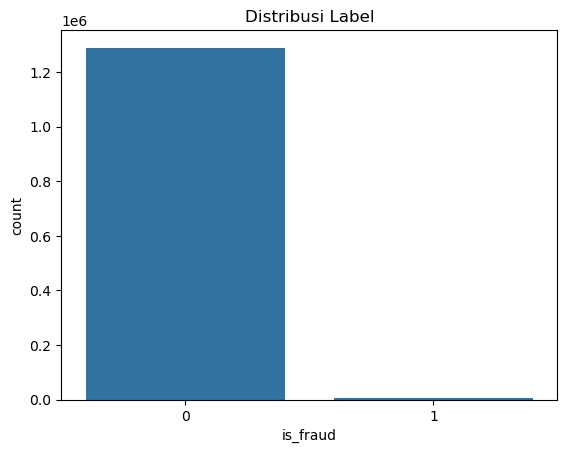

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=new_df_train['is_fraud'])
plt.title('Distribusi Label')
plt.show()

print(new_df_train['is_fraud'].value_counts())
print(new_df_train['is_fraud'].value_counts(normalize=True))

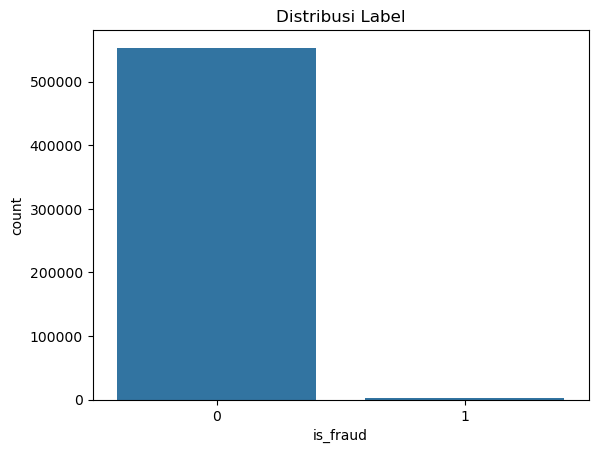

is_fraud
0    553574
1      2145
Name: count, dtype: int64
is_fraud
0    0.99614
1    0.00386
Name: proportion, dtype: float64


In [14]:
sns.countplot(x=new_df_test['is_fraud'])
plt.title('Distribusi Label')
plt.show()

print(new_df_test['is_fraud'].value_counts())
print(new_df_test['is_fraud'].value_counts(normalize=True))

## Correlation Analysis

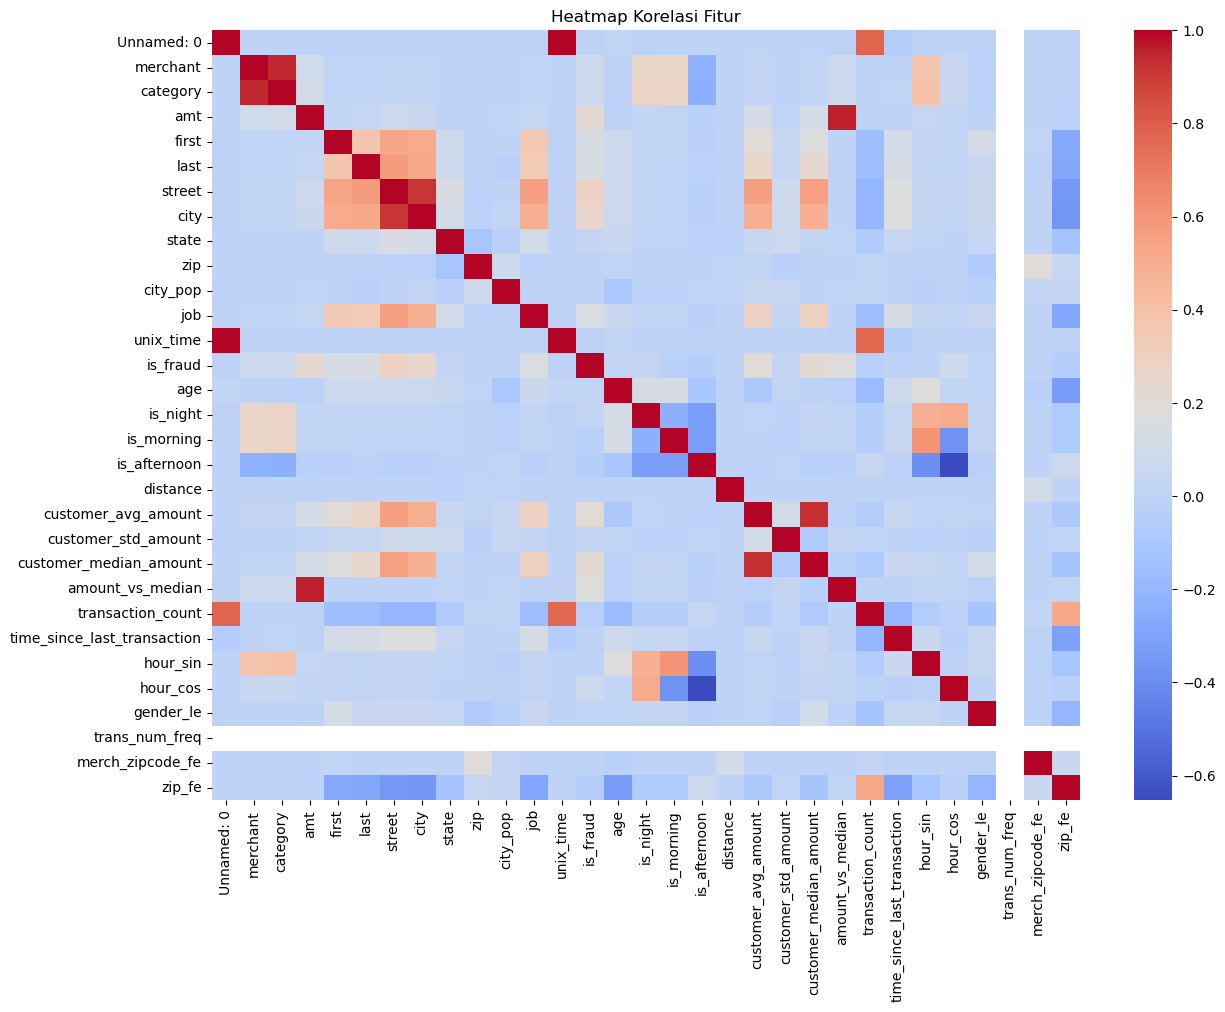

is_fraud                       1.000000
street                         0.286218
city                           0.250262
amt                            0.219404
customer_median_amount         0.216456
customer_avg_amount            0.209960
amount_vs_median               0.179191
job                            0.151403
last                           0.139755
first                          0.129136
hour_cos                       0.079343
merchant                       0.073103
category                       0.070725
state                          0.030408
is_night                       0.029622
customer_std_amount            0.027645
age                            0.012244
gender_le                      0.007642
hour_sin                       0.003718
city_pop                       0.002136
distance                       0.000403
merch_zipcode_fe               0.000233
zip                           -0.002162
time_since_last_transaction   -0.002961
Unnamed: 0                    -0.004767


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
corr = new_df_train.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Heatmap Korelasi Fitur")
plt.show()

# Korelasi terhadap label
corr_label = corr['is_fraud'].sort_values(ascending=False)
print(corr_label)

In [16]:
new_df_train = new_df_train.drop(["Unnamed: 0", "unix_time"], axis=1)
new_df_test = new_df_test.drop(["Unnamed: 0", "unix_time"], axis=1)

## Split

In [17]:
y_train = new_df_train["is_fraud"]
y_test  = new_df_test["is_fraud"]

X_train = new_df_train.drop("is_fraud", axis=1)
X_test  = new_df_test.drop("is_fraud", axis=1)

In [18]:
print(X_train.describe())

           merchant      category           amt         first          last  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   5.788652e-03  5.788652e-03  7.035104e+01  5.705010e-03  5.696501e-03   
std    5.545827e-03  5.365389e-03  1.603160e+02  4.816886e-03  5.449062e-03   
min    0.000000e+00  1.548691e-03  1.000000e+00  0.000000e+00  0.000000e+00   
25%    1.774623e-03  2.114389e-03  9.650000e+00  3.823280e-03  3.424239e-03   
50%    3.337041e-03  2.948165e-03  4.752000e+01  5.377147e-03  4.891171e-03   
75%    8.239376e-03  7.225384e-03  8.314000e+01  7.012271e-03  7.163324e-03   
max    2.572347e-02  1.756149e-02  2.894890e+04  4.780597e-01  4.780597e-01   

             street          city         state           zip      city_pop  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   5.378756e-03  5.470713e-03  5.783474e-03  4.880067e+04  8.882444e+04   
std    8.477189e-03  7.844809e-03  1.365293e-03  2.

## Handle Outliers

In [19]:
X_train = X_train.drop("trans_num_freq", axis=1)
X_test = X_test.drop("trans_num_freq", axis=1)

# Log-transform fitur dengan outlier berat
for col in ["amt", "amount_vs_median", "customer_avg_amount",
            "customer_std_amount", "customer_median_amount",
            "city_pop", "time_since_last_transaction", "transaction_count"]:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col]  = np.log1p(X_test[col])

## After Handling Outliers

In [20]:
print(X_train.describe())

           merchant      category           amt         first          last  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   5.788652e-03  5.788652e-03  3.533470e+00  5.705010e-03  5.696501e-03   
std    5.545827e-03  5.365389e-03  1.289448e+00  4.816886e-03  5.449062e-03   
min    0.000000e+00  1.548691e-03  6.931472e-01  0.000000e+00  0.000000e+00   
25%    1.774623e-03  2.114389e-03  2.365560e+00  3.823280e-03  3.424239e-03   
50%    3.337041e-03  2.948165e-03  3.881976e+00  5.377147e-03  4.891171e-03   
75%    8.239376e-03  7.225384e-03  4.432482e+00  7.012271e-03  7.163324e-03   
max    2.572347e-02  1.756149e-02  1.027332e+01  4.780597e-01  4.780597e-01   

             street          city         state           zip      city_pop  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   5.378756e-03  5.470713e-03  5.783474e-03  4.880067e+04  8.361734e+00   
std    8.477189e-03  7.844809e-03  1.365293e-03  2.

## Data Normalization

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

## Check Noise

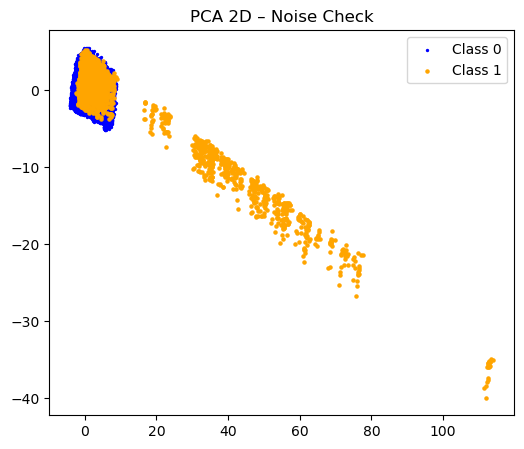

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = X_train_scaled_df
y = y_train

sc = StandardScaler()
Xs = sc.fit_transform(X)

pca = PCA(n_components=2)
Xp = pca.fit_transform(Xs)

plt.figure(figsize=(6,5))
plt.scatter(Xp[y==0,0], Xp[y==0,1], s=2, label="Class 0", color="blue")
plt.scatter(Xp[y==1,0], Xp[y==1,1], s=5, label="Class 1", color="orange")
plt.legend()
plt.title("PCA 2D – Noise Check")
plt.show()

### Handle Noise

In [23]:
# Pisahkan class 1
X_c0_scaled = X_train_scaled_df[y_train == 0]
X_c1_scaled = X_train_scaled_df[y_train == 1]

In [24]:
from sklearn.svm import OneClassSVM

oc = OneClassSVM(
    kernel="rbf",
    nu=0.05,       # persentase noise yang mau dibuang (adjust)
    gamma="scale"
)

labels = oc.fit_predict(X_c1_scaled)

X_c1_scaled_clean = X_c1_scaled[labels == 1]
noise_c1   = X_c1_scaled[labels == -1]

print("Noise removed:", len(noise_c1))

Noise removed: 373


In [25]:
# Gabung dengan class 0
X_train_clean = np.concatenate([X_c0_scaled, X_c1_scaled_clean])
y_train_clean = np.concatenate([
    np.zeros(len(X_c0_scaled)),
    np.ones(len(X_c1_scaled_clean))
])

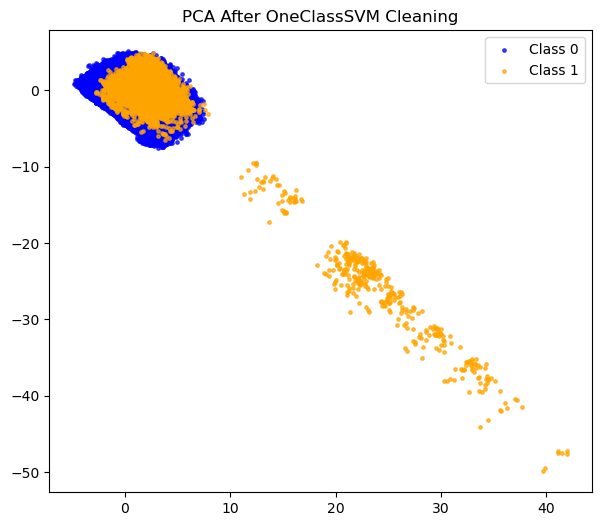

In [26]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_clean = np.vstack([X_c0_scaled, X_c1_scaled_clean])
y_clean = np.hstack([
    np.zeros(len(X_c0_scaled)),
    np.ones(len(X_c1_scaled_clean))
])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'label': y_clean
})

plt.figure(figsize=(7,6))

plt.scatter(
    df_plot[df_plot.label == 0].PC1,
    df_plot[df_plot.label == 0].PC2,
    s=6, alpha=0.7, label="Class 0", color="blue"
)

plt.scatter(
    df_plot[df_plot.label == 1].PC1,
    df_plot[df_plot.label == 1].PC2,
    s=6, alpha=0.7, label="Class 1", color="orange"
)

plt.title("PCA After OneClassSVM Cleaning")
plt.legend()
plt.show()

In [27]:
X_train_clean_df = pd.DataFrame(
    X_train_clean,
    columns=X_train.columns
)

# Feature Selection

## Random Forest Feature Importances

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=50,
    n_jobs=-1
)

rf.fit(X_train_clean, y_train_clean)

feat_imp = pd.Series(rf.feature_importances_, index=X_train_clean_df.columns)
top_features = feat_imp.sort_values(ascending=False).head(10).index.tolist()

print(top_features)

['amt', 'amount_vs_median', 'category', 'hour_cos', 'time_since_last_transaction', 'street', 'merchant', 'customer_median_amount', 'age', 'city']


In [28]:
top_5_features = ['amt', 'amount_vs_median', 'category', 'hour_cos', 'time_since_last_transaction']
top_10_features = ['amt', 'amount_vs_median', 'category', 'hour_cos', 'time_since_last_transaction',
                    'street', 'merchant', 'customer_median_amount', 'age', 'city']

# Train & Predict

In [29]:
X_train_clean_5 = X_train_clean_df[top_5_features]
X_train_clean_10 = X_train_clean_df[top_10_features]
X_test_5 = X_test_scaled_df[top_5_features]
X_test_10 = X_test_scaled_df[top_10_features]

## Top 5 Features

### Random Forest

              precision    recall  f1-score   support

           0     0.9989    0.9996    0.9993    553574
           1     0.8746    0.7249    0.7928      2145

    accuracy                         0.9985    555719
   macro avg     0.9368    0.8623    0.8960    555719
weighted avg     0.9985    0.9985    0.9985    555719


=== ROC-AUC ===
0.9853744571101238


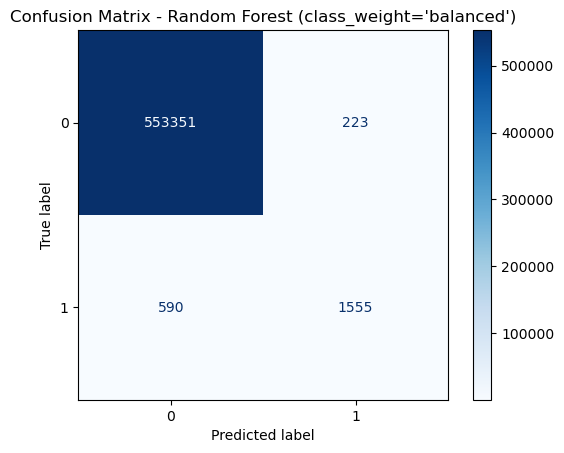

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=50,
    n_jobs=-1
)
rf.fit(X_train_clean_5, y_train_clean)

# Predict test
rf_pred_top_5 = rf.predict(X_test_5)
rf_proba_top_5 = rf.predict_proba(X_test_5)[:, 1]

print(classification_report(y_test, rf_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, rf_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest (class_weight='balanced')")
plt.show()

Best threshold (F1-optimal): 0.48

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9990    0.9996    0.9993    553574
           1     0.8664    0.7347    0.7952      2145

    accuracy                         0.9985    555719
   macro avg     0.9327    0.8671    0.8972    555719
weighted avg     0.9985    0.9985    0.9985    555719


=== ROC-AUC ===
0.9853744571101238


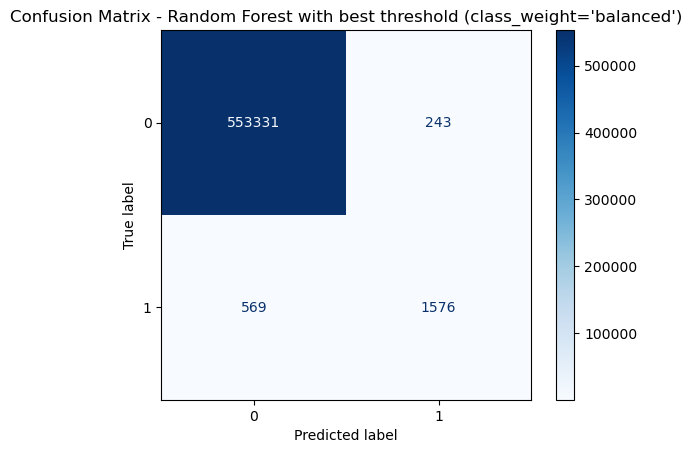

In [31]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, rf_proba_top_5)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
rf_y_pred_top_5 = (rf_proba_top_5 >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, rf_y_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, rf_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_y_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest with best threshold (class_weight='balanced')")
plt.show()

### Logistic Regression

              precision    recall  f1-score   support

           0     0.9989    0.8365    0.9105    553574
           1     0.0178    0.7636    0.0347      2145

    accuracy                         0.8362    555719
   macro avg     0.5083    0.8001    0.4726    555719
weighted avg     0.9951    0.8362    0.9071    555719


=== ROC-AUC ===
0.8979417941760826


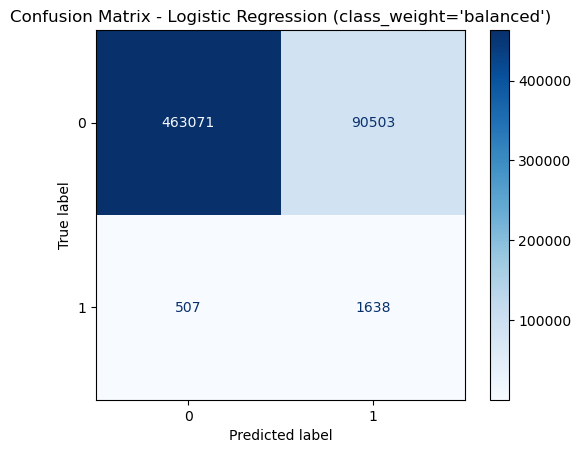

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(X_train_clean_5, y_train_clean)

# Predict test
lr_pred_top_5 = lr.predict(X_test_5)
lr_proba_top_5 = lr.predict_proba(X_test_5)[:, 1]

print(classification_report(y_test, lr_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, lr_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, lr_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression (class_weight='balanced')")
plt.show()

Best threshold (F1-optimal): 0.9336687049054476

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9977    0.9972    0.9975    553574
           1     0.3642    0.4121    0.3867      2145

    accuracy                         0.9950    555719
   macro avg     0.6810    0.7047    0.6921    555719
weighted avg     0.9953    0.9950    0.9951    555719


=== ROC-AUC ===
0.8979417941760826


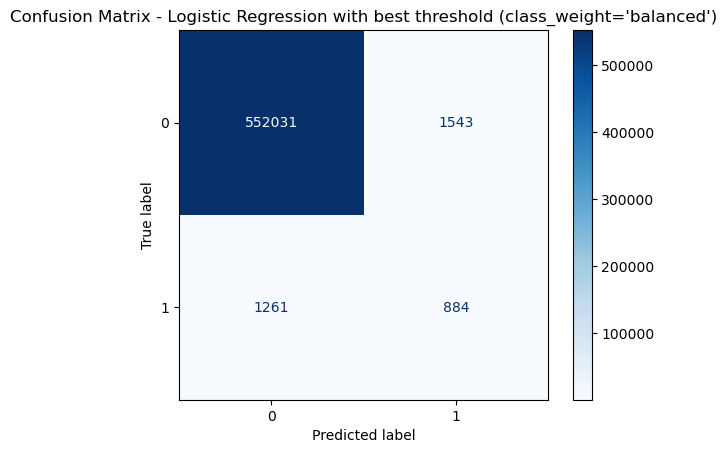

In [33]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, lr_proba_top_5)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
lr_y_pred_top_5 = (lr_proba_top_5 >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, lr_y_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, lr_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, lr_y_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression with best threshold (class_weight='balanced')")
plt.show()

### XGBoost

In [34]:
neg = (y_train_clean == 0).sum()
pos = (y_train_clean == 1).sum()
scale_pos_weight = neg / pos
print(scale_pos_weight)

180.73307163886162


              precision    recall  f1-score   support

           0     0.9999    0.9806    0.9901    553574
           1     0.1618    0.9669    0.2772      2145

    accuracy                         0.9805    555719
   macro avg     0.5808    0.9737    0.6337    555719
weighted avg     0.9966    0.9805    0.9874    555719


=== ROC-AUC ===
0.996912289130493


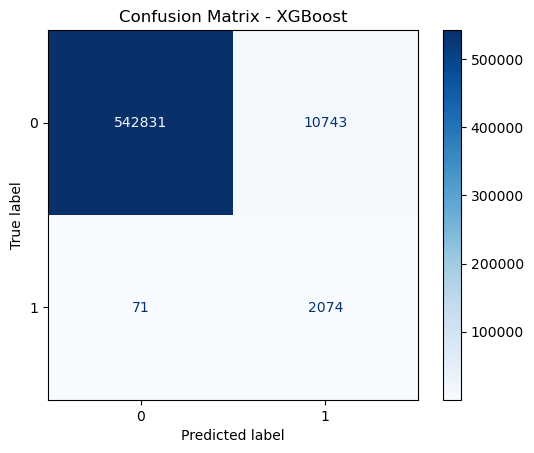

In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=50,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)
xgb.fit(X_train_clean_5, y_train_clean)

# Predict test
xgb_pred_top_5 = xgb.predict(X_test_5)
xgb_proba_top_5 = xgb.predict_proba(X_test_5)[:, 1]

print(classification_report(y_test, xgb_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, xgb_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, xgb_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

Best threshold (F1-optimal): 0.9849229

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9989    0.9992    0.9990    553574
           1     0.7655    0.7138    0.7387      2145

    accuracy                         0.9981    555719
   macro avg     0.8822    0.8565    0.8689    555719
weighted avg     0.9980    0.9981    0.9980    555719


=== ROC-AUC ===
0.996912289130493


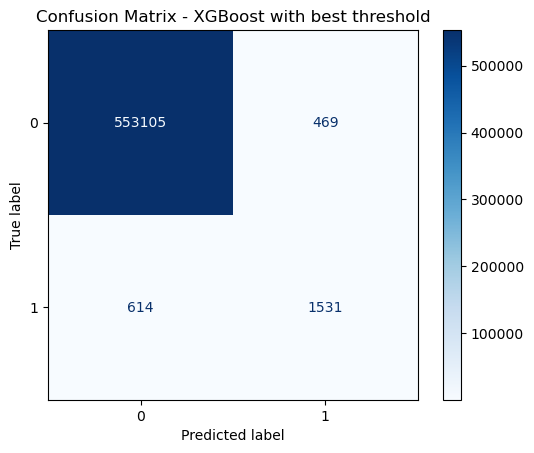

In [36]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, xgb_proba_top_5)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
xgb_y_pred_top_5 = (xgb_proba_top_5 >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, xgb_y_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, xgb_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, xgb_y_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - XGBoost with best threshold")
plt.show()

### TabNet

In [51]:
import numpy as np
import torch
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal.mean()

In [52]:
focal_loss = FocalLoss(alpha=0.25, gamma=2)

clf = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', # lebih stabil untuk imbalance
    verbose=10
)

clf.fit(
    X_train=X_train_clean_5.values,
    y_train=y_train_clean,
    eval_set=[(X_test_5.values, y_test)],
    eval_metric=['auc'],
    max_epochs=30,
    batch_size=2048,
    virtual_batch_size=256,
    loss_fn=focal_loss,
    patience=10
)

d:\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.00946 | val_0_auc: 0.9051  |  0:00:41s
epoch 10 | loss: 0.00138 | val_0_auc: 0.97024 |  0:07:20s
epoch 20 | loss: 0.00104 | val_0_auc: 0.98037 |  0:14:43s
Stop training because you reached max_epochs = 30 with best_epoch = 25 and best_val_0_auc = 0.9829


d:\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9979    0.9993    0.9986    553574
           1     0.7294    0.4550    0.5604      2145

    accuracy                         0.9972    555719
   macro avg     0.8637    0.7272    0.7795    555719
weighted avg     0.9969    0.9972    0.9969    555719


=== ROC-AUC ===
0.9829030865613148


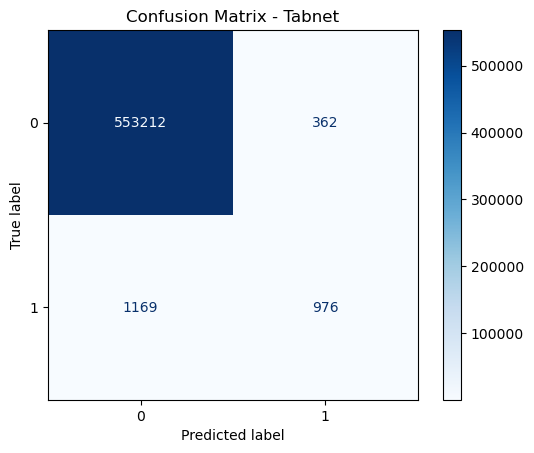

In [53]:
# Predict test
y_proba_top_5 = clf.predict_proba(X_test_5.values)[:, 1]
y_pred_top_5 = (y_proba_top_5 >= 0.5).astype(int)

# Evaluation
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_top_5, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, y_proba_top_5))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Tabnet")
plt.show()

## Top 10 Features

### Random Forest

              precision    recall  f1-score   support

           0     0.9964    0.9997    0.9980    553574
           1     0.4671    0.0662    0.1160      2145

    accuracy                         0.9961    555719
   macro avg     0.7317    0.5330    0.5570    555719
weighted avg     0.9944    0.9961    0.9946    555719


=== ROC-AUC ===
0.72085341296034


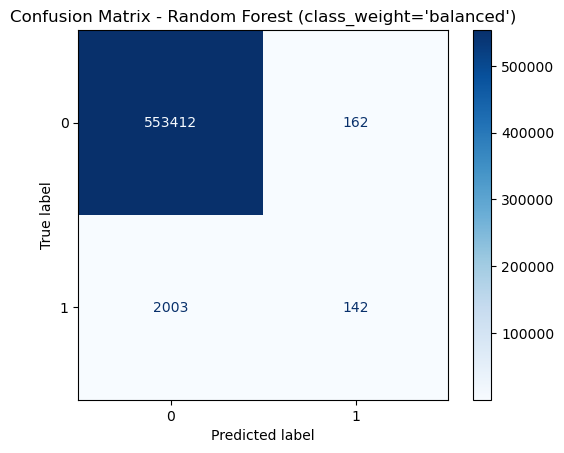

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=50,
    n_jobs=-1
)
rf.fit(X_train_clean_10, y_train_clean)

# Predict test
rf_pred_top_10 = rf.predict(X_test_10)
rf_proba_top_10 = rf.predict_proba(X_test_10)[:, 1]

print(classification_report(y_test, rf_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, rf_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest (class_weight='balanced')")
plt.show()

Best threshold (F1-optimal): 0.414

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9964    0.9996    0.9980    553574
           1     0.3959    0.0718    0.1215      2145

    accuracy                         0.9960    555719
   macro avg     0.6962    0.5357    0.5598    555719
weighted avg     0.9941    0.9960    0.9946    555719


=== ROC-AUC ===
0.72085341296034


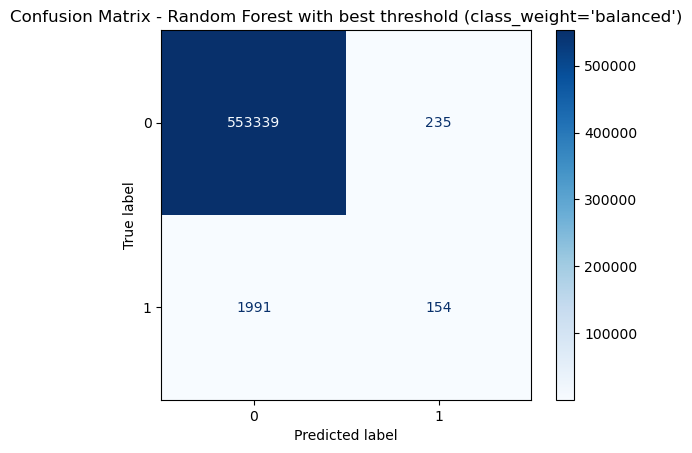

In [38]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, rf_proba_top_10)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
rf_y_pred_top_10 = (rf_proba_top_10 >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, rf_y_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, rf_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_y_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest with best threshold (class_weight='balanced')")
plt.show()

### Logistic Regression

              precision    recall  f1-score   support

           0     0.9987    0.9057    0.9499    553574
           1     0.0278    0.6956    0.0534      2145

    accuracy                         0.9049    555719
   macro avg     0.5132    0.8006    0.5017    555719
weighted avg     0.9950    0.9049    0.9465    555719


=== ROC-AUC ===
0.8656089322612679


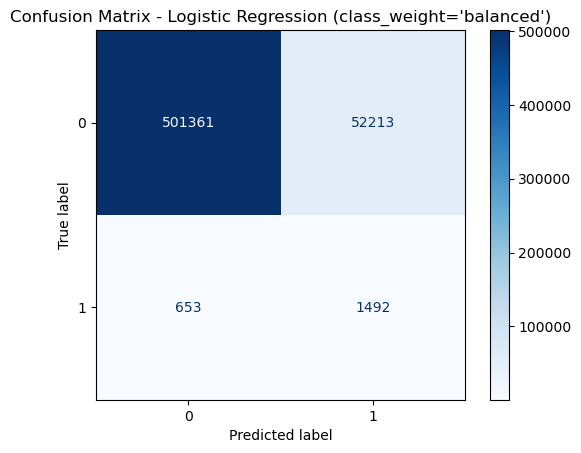

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(X_train_clean_10, y_train_clean)

# Predict test
lr_pred_top_10 = lr.predict(X_test_10)
lr_proba_top_10 = lr.predict_proba(X_test_10)[:, 1]

print(classification_report(y_test, lr_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, lr_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, lr_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression (class_weight='balanced')")
plt.show()

Best threshold (F1-optimal): 0.9588606411808361

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9972    0.9957    0.9965    553574
           1     0.2011    0.2788    0.2337      2145

    accuracy                         0.9929    555719
   macro avg     0.5992    0.6372    0.6151    555719
weighted avg     0.9941    0.9929    0.9935    555719


=== ROC-AUC ===
0.8656089322612679


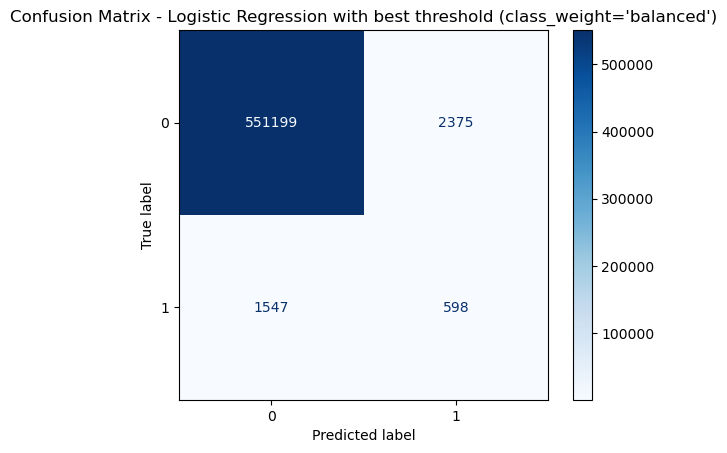

In [40]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, lr_proba_top_10)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
lr_y_pred_top_10 = (lr_proba_top_10 >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, lr_y_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, lr_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, lr_y_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression with best threshold (class_weight='balanced')")
plt.show()

### XGBoost

              precision    recall  f1-score   support

           0     0.9964    0.9856    0.9910    553574
           1     0.0215    0.0816    0.0340      2145

    accuracy                         0.9821    555719
   macro avg     0.5089    0.5336    0.5125    555719
weighted avg     0.9926    0.9821    0.9873    555719


=== ROC-AUC ===
0.7962178451948564


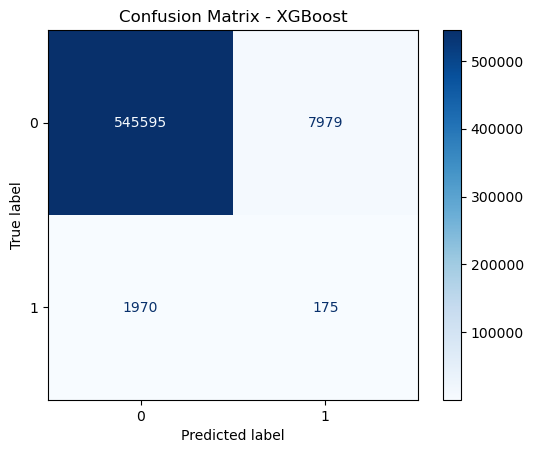

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=50,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)
xgb.fit(X_train_clean_10, y_train_clean)

# Predict test
xgb_pred_top_10 = xgb.predict(X_test_10)
xgb_proba_top_10 = xgb.predict_proba(X_test_10)[:, 1]

print(classification_report(y_test, xgb_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, xgb_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, xgb_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

Best threshold (F1-optimal): 0.9861566

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9964    0.9994    0.9979    553574
           1     0.2915    0.0639    0.1048      2145

    accuracy                         0.9958    555719
   macro avg     0.6439    0.5316    0.5513    555719
weighted avg     0.9937    0.9958    0.9944    555719


=== ROC-AUC ===
0.7962178451948564


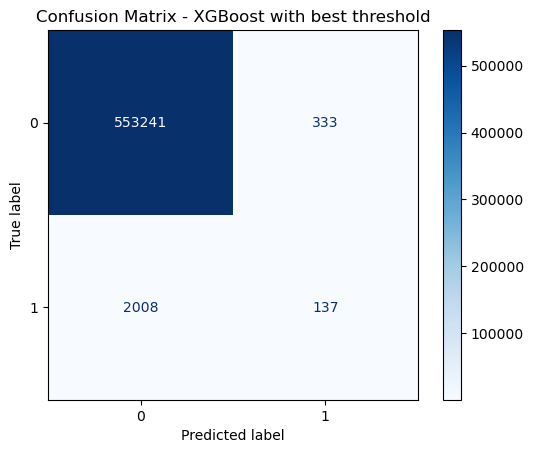

In [42]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, xgb_proba_top_10)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
xgb_y_pred_top_10 = (xgb_proba_top_10 >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, xgb_y_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, xgb_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, xgb_y_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - XGBoost with best threshold")
plt.show()

### TabNet

In [54]:
import numpy as np
import torch
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    ConfusionMatrixDisplay
)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal.mean()

In [55]:
focal_loss = FocalLoss(alpha=0.25, gamma=2)

clf = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', # lebih stabil untuk imbalance
    verbose=10
)

clf.fit(
    X_train=X_train_clean_10.values,
    y_train=y_train_clean,
    eval_set=[(X_test_10.values, y_test)],
    eval_metric=['auc'],
    max_epochs=30,
    batch_size=2048,
    virtual_batch_size=256,
    loss_fn=focal_loss,
    patience=10
)

d:\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.00568 | val_0_auc: 0.71369 |  0:00:43s
epoch 10 | loss: 0.00128 | val_0_auc: 0.88321 |  0:07:37s
epoch 20 | loss: 0.00108 | val_0_auc: 0.88489 |  0:14:19s

Early stopping occurred at epoch 24 with best_epoch = 14 and best_val_0_auc = 0.89926


d:\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9963    0.9992    0.9977    553574
           1     0.1630    0.0420    0.0667      2145

    accuracy                         0.9955    555719
   macro avg     0.5797    0.5206    0.5322    555719
weighted avg     0.9931    0.9955    0.9941    555719


=== ROC-AUC ===
0.8992576722654364


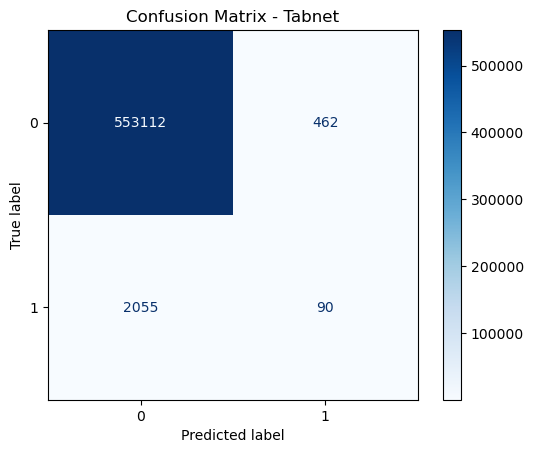

In [56]:
# Predict test
y_proba_top_10 = clf.predict_proba(X_test_10.values)[:, 1]
y_pred_top_10 = (y_proba_top_10 >= 0.5).astype(int)

# Evaluation
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_top_10, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, y_proba_top_10))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_top_10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Tabnet")
plt.show()

In [57]:
explain_matrix, masks = clf.explain(X_test_10.values)

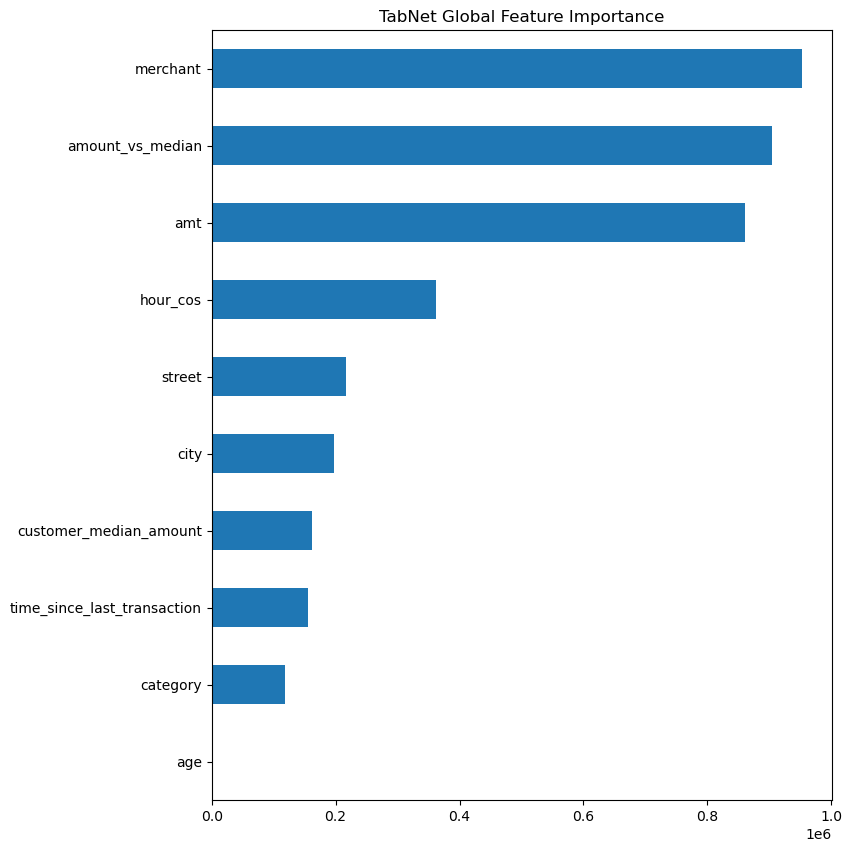

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TabNet feature importance = sum explain_matrix across samples
feat_imp = explain_matrix.sum(axis=0)

feat_series = pd.Series(feat_imp, index=X_test_10.columns)

plt.figure(figsize=(8, 10))
feat_series.sort_values().plot(kind='barh')
plt.title("TabNet Global Feature Importance")
plt.show()

# RandomizedSearchCV

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=50
)

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(6, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=2,
    verbose=1,
    random_state=50,
    n_jobs=-1
)

rs.fit(X_train_clean_5, y_train_clean)

print("Best Params =", rs.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Params = {'bootstrap': True, 'max_depth': 22, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 239}


# Tuned Model

              precision    recall  f1-score   support

           0     0.9990    0.9994    0.9992    553574
           1     0.8233    0.7408    0.7799      2145

    accuracy                         0.9984    555719
   macro avg     0.9112    0.8701    0.8895    555719
weighted avg     0.9983    0.9984    0.9983    555719


=== ROC-AUC ===
0.9875301578116378


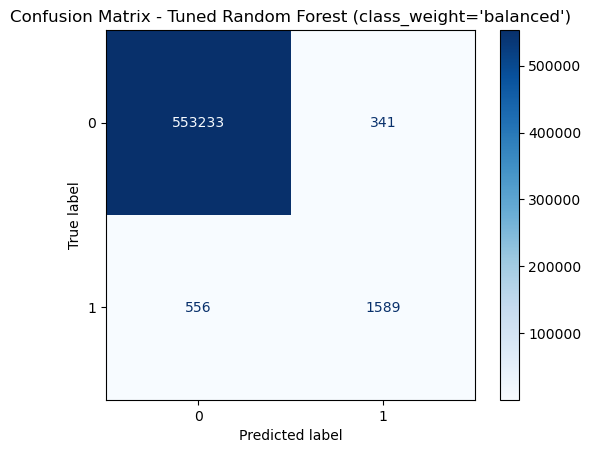

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train
rf_tuned = RandomForestClassifier(
    bootstrap=True,
    max_depth=22,
    max_features=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=239,
    random_state=50,
    n_jobs=-1
)
rf_tuned.fit(X_train_clean_5, y_train_clean)

# Predict test
rf_pred_tuned = rf_tuned.predict(X_test_5)
rf_proba_tuned = rf_tuned.predict_proba(X_test_5)[:, 1]

print(classification_report(y_test, rf_pred_tuned, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, rf_proba_tuned))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Tuned Random Forest (class_weight='balanced')")
plt.show()

Best threshold (F1-optimal): 0.5308620411791203

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9990    0.9995    0.9992    553574
           1     0.8388    0.7329    0.7823      2145

    accuracy                         0.9984    555719
   macro avg     0.9189    0.8662    0.8907    555719
weighted avg     0.9983    0.9984    0.9984    555719


=== ROC-AUC ===
0.9875301578116378


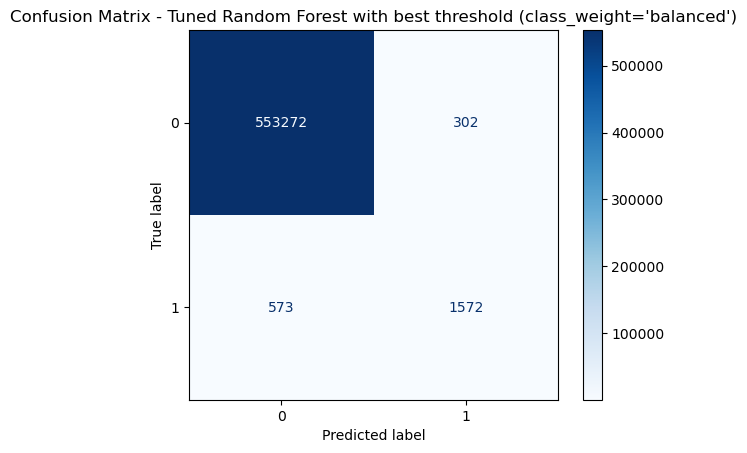

In [44]:
from sklearn.metrics import precision_recall_curve

# Predict
prec, rec, thr = precision_recall_curve(y_test, rf_proba_tuned)

# Hitung F1
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

if best_idx == 0:
    best_thr = thr[0]
else:
    best_thr = thr[best_idx-1]

print("Best threshold (F1-optimal):", best_thr)

# Convert probabilitas -> label biner
rf_y_pred_tuned = (rf_proba_tuned >= best_thr).astype(int)

# Evaluation
print("\n=== Classification Report ===")
print(classification_report(y_test, rf_y_pred_tuned, digits=4))

print("\n=== ROC-AUC ===")
print(roc_auc_score(y_test, rf_proba_tuned))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Tuned Random Forest with best threshold (class_weight='balanced')")
plt.show()